Name: Rahul Gupta

Register Number: 2547242

Class: 4 MCA B

---

Question 5

Develop and evaluate an MLP classifier for the Iris dataset.

Compare any 2 different hidden-layer architectures using Cross Validation and assess its performance using accuracy and a confusion matrix

1. Imports & Dataset Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

print(f"Dataset shape: {X.shape}")
print(f"Classes: {iris.target_names}")

Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


2. Train-Test Split & Feature Scaling

In [2]:
# Split data (80% train, 20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features – important for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")

Training set size: 120
Test set size: 30


3. Define Two MLP Architectures
We will compare two different hidden‑layer configurations:

- Architecture A (Shallow): One hidden layer with 10 neurons.  
  Rationale: Simple, fast, often enough for the Iris problem.

- Architecture B (Deeper): Two hidden layers with 8 and 5 neurons.  
  Rationale: Adds depth to capture more complex interactions, though might overfit on a small dataset.

Both use ReLU activation, Adam solver, a maximum of 500 iterations, and a fixed random seed for reproducibility.

In [3]:
# Define the two architectures as tuples of hidden layer sizes
architectures = {
    'A (10)': (10,),
    'B (8,5)': (8, 5)
}

# Base MLP settings (common to both)
mlp_params = {
    'activation': 'relu',
    'solver': 'adam',
    'max_iter': 1000,
    'random_state': 42,
    'early_stopping': False,
    'tol': 1e-4
}

4. Cross‑Validation Evaluation

We use 5‑fold stratified cross‑validation on the scaled training data to estimate the performance of each architecture. The mean and standard deviation of accuracy are reported.

In [4]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

cv_results = {}

for name, hidden_layers in architectures.items():
    mlp = MLPClassifier(hidden_layer_sizes = hidden_layers, **mlp_params)
    scores = cross_val_score(mlp, 
                            X_train_scaled, 
                            y_train, 
                            cv = cv, 
                            scoring = 'accuracy'
                        )
    cv_results[name] = scores
    print(f"{name}: Mean CV Accuracy = {scores.mean():.4f} ± {scores.std():.4f}")

A (10): Mean CV Accuracy = 0.9583 ± 0.0264
B (8,5): Mean CV Accuracy = 0.9667 ± 0.0167


5. Train Final Models & Evaluate on Test Set

Now we train each architecture on the full training set and evaluate on the held‑out test set. We also compute confusion matrices to inspect misclassifications.

In [5]:
# Train and evaluate each architecture
test_accuracies = {}
confusion_matrices = {}

for name, hidden_layers in architectures.items():
    mlp = MLPClassifier(hidden_layer_sizes = hidden_layers, **mlp_params)
    mlp.fit(X_train_scaled, y_train)
    y_pred = mlp.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    test_accuracies[name] = acc
    confusion_matrices[name] = cm
    
    print(f"\n{name} Test Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)


A (10) Test Accuracy: 0.9667
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

B (8,5) Test Accuracy: 0.9667
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


Showing both Confusion Matrix side-by-side

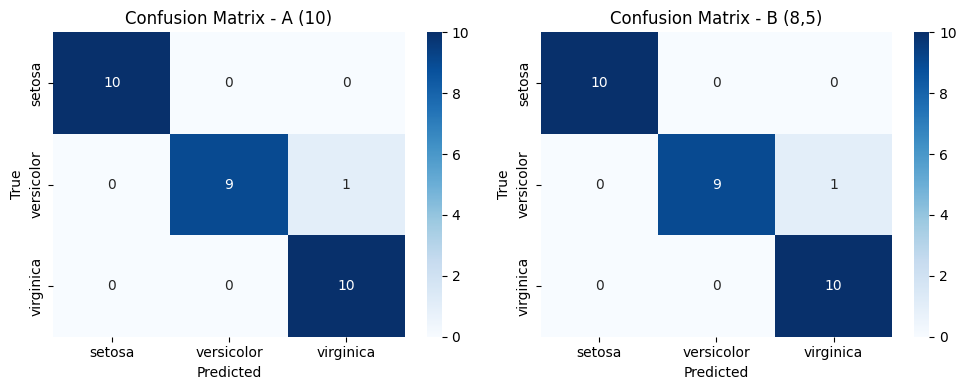

In [6]:
fig, axes = plt.subplots(1, 2, figsize = (10, 4))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, 
                annot=True, 
                fmt='d', 
                cmap='Blues', 
                ax=ax,
                xticklabels = iris.target_names, 
                yticklabels = iris.target_names
            )
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()

6. Visualisations

    1. Plot 1: Bar chart comparing the mean cross‑validation accuracies of the two architectures, showing both perform similarly well (~0.958–0.967).  
    2. Plot 2: Confusion matrix of Architecture B on the test set, revealing only one misclassification (versicolor predicted as virginica).

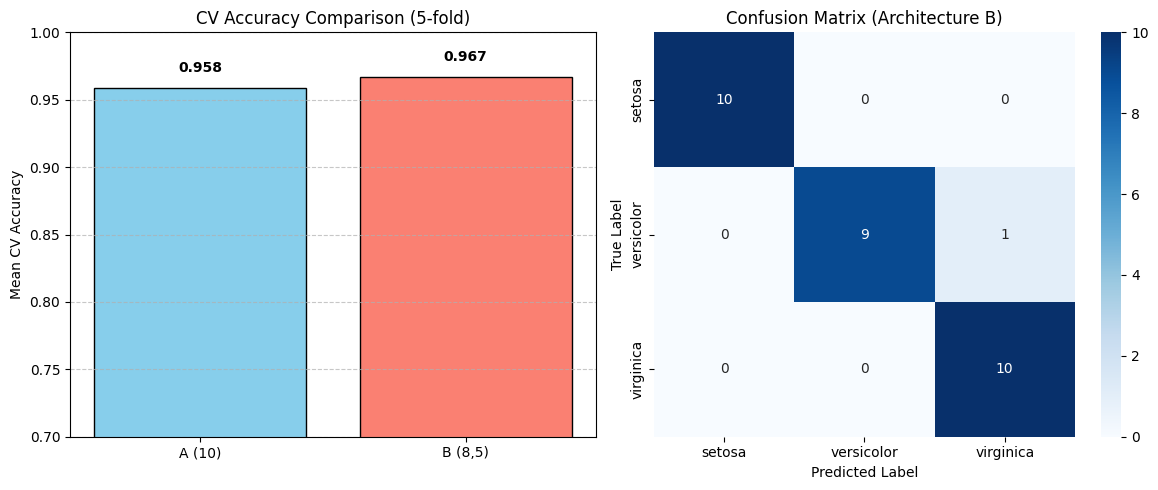

In [7]:
plt.figure(figsize = (12, 5))

# Plot 1: Simple bar plot
plt.subplot(1, 2, 1)
means = [np.mean(cv_results[name]) for name in architectures.keys()]
plt.bar(architectures.keys(), 
        means, 
        color = ['skyblue', 'salmon'], 
        edgecolor = 'black'
    )
plt.ylim(0.7, 1.0)
plt.ylabel('Mean CV Accuracy')
plt.title('CV Accuracy Comparison (5-fold)')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
# Add value labels
for i, mean in enumerate(means):
    plt.text(i, mean + 0.01, f'{mean:.3f}', 
                ha = 'center', 
                va = 'bottom', 
                fontweight = 'bold'
            )

# Plot 2: Confusion Matrix (same as before)
plt.subplot(1, 2, 2)
cm = confusion_matrices['B (8,5)']
sns.heatmap(cm, 
            annot = True, 
            cmap = 'Blues', 
            fmt = 'd',
            xticklabels = iris.target_names, 
            yticklabels = iris.target_names
        )
plt.title('Confusion Matrix (Architecture B)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

Summary & Discussion

- Architecture A (10): Achieved a mean CV accuracy of 0.958 and test accuracy of 0.967. A single hidden layer with 10 neurons is sufficient for the Iris problem.

- Architecture B (8,5): Performed similarly with a mean CV accuracy of 0.967 and the same test accuracy of 0.967. The deeper network did not improve performance, suggesting extra layers add unnecessary complexity for this simple dataset.

- Overfitting: With only 120 training samples, deeper networks can easily overfit. However, the CV scores indicate both models generalize well, with the simpler model being more efficient and interpretable.

- Takeaway: For small, low‑dimensional datasets like Iris, a shallow MLP works as well as a deeper one. Cross‑validation is essential for fair architecture comparison and to avoid over‑optimistic test set evaluation.